# CNN Fruit Classifier

This notebook trains a CNN on the fruit dataset in `data/raw/fruits` and saves the model to `src/models/modelCNN.h5`.

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

2026-03-05 21:10:04.459263: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-05 21:10:04.548138: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-05 21:10:07.619419: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
# Paths (notebook is in notebooks/)
BASE_DIR = os.path.abspath('..')
DATA_DIR = os.path.join(BASE_DIR, 'data', 'raw', 'fruits')
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
VAL_DIR = os.path.join(DATA_DIR, 'validation')
TEST_DIR = os.path.join(DATA_DIR, 'test')
MODEL_PATH = os.path.join(BASE_DIR, 'src', 'models', 'modelCNN.h5')

for p in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if not os.path.isdir(p):
        raise FileNotFoundError(f'Missing dataset folder: {p}')

os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
print('Train:', TRAIN_DIR)
print('Validation:', VAL_DIR)
print('Test:', TEST_DIR)
print('Model output:', MODEL_PATH)

Train: /home/taoufikkehal/Documents/AI ressources/Ai avancee course/CNN TP1/data/raw/fruits/train
Validation: /home/taoufikkehal/Documents/AI ressources/Ai avancee course/CNN TP1/data/raw/fruits/validation
Test: /home/taoufikkehal/Documents/AI ressources/Ai avancee course/CNN TP1/data/raw/fruits/test
Model output: /home/taoufikkehal/Documents/AI ressources/Ai avancee course/CNN TP1/src/models/modelCNN.h5


In [4]:
# Data pipeline
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

test_val_datagen = ImageDataGenerator(rescale=1.0/255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_gen = test_val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = test_val_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(train_gen.class_indices.keys())
num_classes = len(class_names)
print('Classes:', class_names)

Found 460 images belonging to 3 classes.
Found 66 images belonging to 3 classes.
Found 130 images belonging to 3 classes.
Classes: ['apple', 'banana', 'orange']


In [5]:
# CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/home/taoufikkehal/Downloads/ml_env/lib64/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-05 21:10:09.226447: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,516,803 (24.86 MB)

 Trainable params: 6,516,803 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Training
EPOCHS = 20

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint(MODEL_PATH, monitor='val_accuracy', save_best_only=True)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 799ms/step - accuracy: 0.4803 - loss: 1.0801

15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 926ms/step - accuracy: 0.5891 - loss: 0.9052 - val_accuracy: 0.8182 - val_loss: 0.5694
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 758ms/step - accuracy: 0.7952 - loss: 0.4556

15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 839ms/step - accuracy: 0.8435 - loss: 0.3874 - val_accuracy: 0.9091 - val_loss: 0.3479
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 752ms/step - accuracy: 0.8987 - loss: 0.2595

15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 820ms/step - accuracy: 0.8848 - loss: 0.2648 - val_accuracy: 0.9697 - val_loss: 0.0973
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 837ms/step - accuracy: 0.9196 - loss: 0.2137 - val_accuracy: 0.8939 - val_loss: 0.3222
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 896ms/step - accuracy: 0.9435 - loss: 0.1860 - val_accuracy: 0.9545 - val_loss: 0.1616
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 809ms/step - accuracy: 0.9261 - loss: 0.2025 - val_accuracy: 0.8485 - val_loss: 0.4351
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 763ms/step - accuracy: 0.9413 - loss: 0.1779 - val_accuracy: 0.9242 - val_loss: 0.1848
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 760ms/step - accuracy: 0.9301 - loss: 0.1644

15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 834ms/step - accuracy: 0.9457 - loss: 0.1296 - val_accuracy: 0.9848 - val_loss: 0.0567
Epoch 9/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 797ms/step - accuracy: 0.9674 - loss: 0.0718 - val_accuracy: 0.9242 - val_loss: 0.1937
Epoch 10/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 810ms/step - accuracy: 0.9587 - loss: 0.1165 - val_accuracy: 0.9697 - val_loss: 0.0864
Epoch 11/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 802ms/step - accuracy: 0.9783 - loss: 0.0613 - val_accuracy: 0.9394 - val_loss: 0.1399
Epoch 12/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 888ms/step - accuracy: 0.9652 - loss: 0.1083 - val_accuracy: 0.9091 - val_loss: 0.2640
Epoch 13/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 895ms/step - accuracy: 0.9848 - loss: 0.0614 - val_accuracy: 0.9697 - val_loss: 0.0707


In [7]:
# Evaluation
test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 238ms/step - accuracy: 0.9615 - loss: 0.1368
Test Loss: 0.1368
Test Accuracy: 0.9615


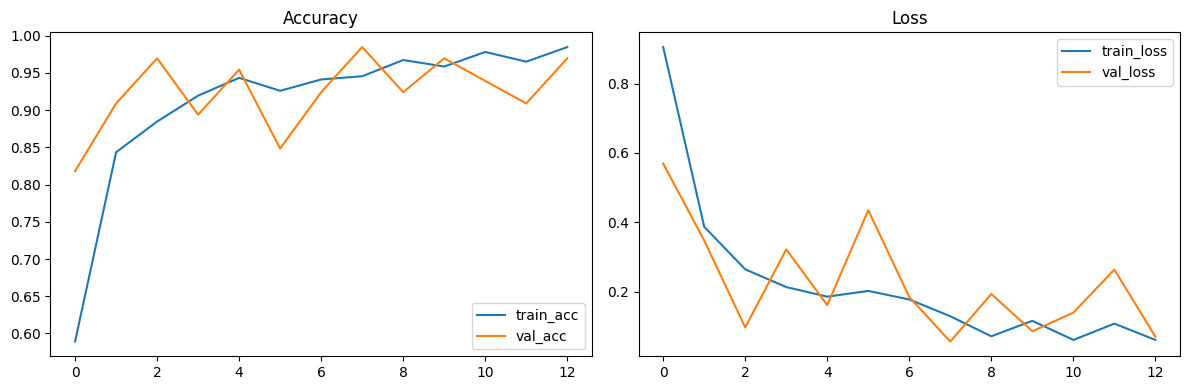

In [8]:
# Plot training curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
# Optional: load best saved model
best_model = tf.keras.models.load_model(MODEL_PATH)
best_loss, best_acc = best_model.evaluate(test_gen, verbose=0)
print(f'Best Saved Model Accuracy: {best_acc:.4f}')

Best Saved Model Accuracy: 0.9615
